In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/sales_project.db")

In [2]:
# Rank of each purchase within each customer, by total price

query = """
SELECT
    Customer_ID,
    DATE(Purchase_Date) AS Purchase_Date,
    Product_Name,
    Total_Price,
    ROW_NUMBER() OVER (
        PARTITION BY Customer_ID
        ORDER BY Total_Price DESC
    ) AS rank_within_customer
FROM Transaction_Records
ORDER BY Customer_ID, rank_within_customer
"""

df_q1 = pd.read_sql_query(query, conn)
print(df_q1)

    Customer_ID Purchase_Date Product_Name  Total_Price  rank_within_customer
0    Customer_1    2022-07-28    Product_6          195                     1
1    Customer_1    2023-11-24    Product_8          169                     2
2    Customer_1    2022-03-11    Product_2          126                     3
3    Customer_1    2023-04-15    Product_7           94                     4
4    Customer_1    2024-12-26    Product_1           78                     5
..          ...           ...          ...          ...                   ...
223  Customer_9    2024-01-05    Product_3           68                     9
224  Customer_9    2022-03-29    Product_6           62                    10
225  Customer_9    2022-08-06    Product_9           32                    11
226  Customer_9    2024-06-14    Product_3           27                    12
227  Customer_9    2022-09-13   Product_10           25                    13

[228 rows x 5 columns]


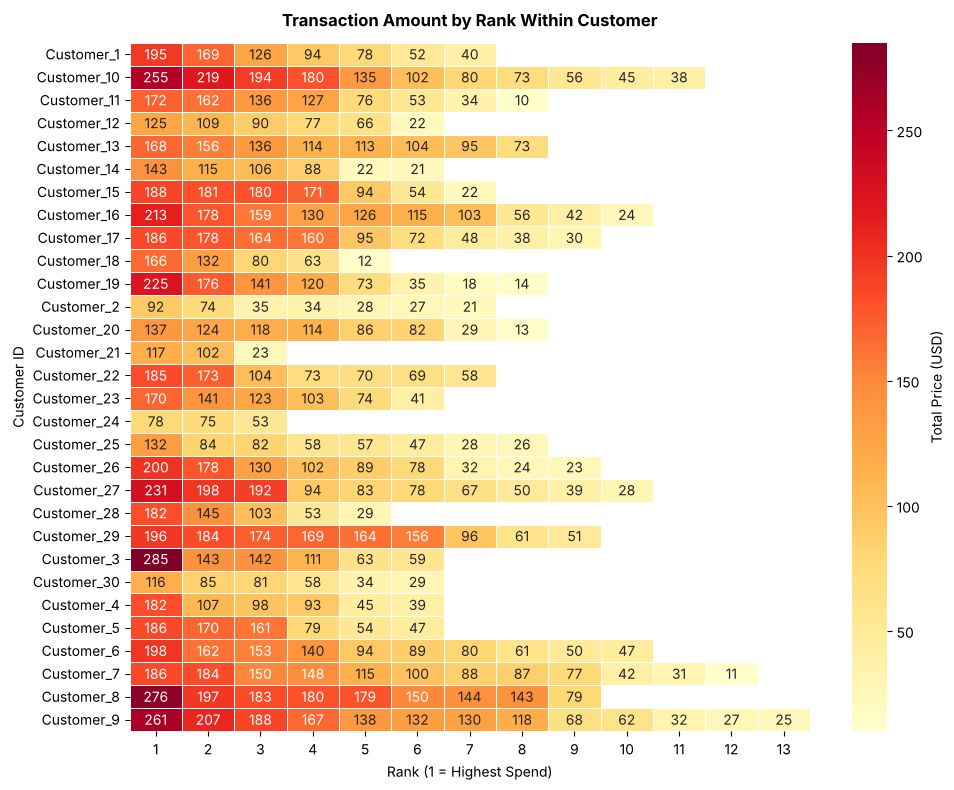

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap of purchase amount by rank within each customer (multi-purchase customers only)

multi = df_q1.groupby("Customer_ID").filter(lambda x: len(x) > 1)
pivot = multi.pivot(
    index="Customer_ID", columns="rank_within_customer", values="Total_Price"
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Total Price (USD)"},
)
ax.set_title("Transaction Amount by Rank Within Customer", fontweight="bold", pad=12)
ax.set_xlabel("Rank (1 = Highest Spend)")
ax.set_ylabel("Customer ID")
plt.tight_layout()
plt.savefig("../images/rank_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Monthly sales and percentage change from the previous month

query = """
WITH monthly_sales AS (
    SELECT
        strftime('%Y-%m', Purchase_Date) AS month,
        ROUND(SUM(Total_Price), 2)       AS total_sales
    FROM Transaction_Records
    GROUP BY month
)
SELECT
    month,
    total_sales,
    LAG(total_sales) OVER (ORDER BY month) AS previous_month_sales,
    ROUND(
        100.0 * (total_sales - LAG(total_sales) OVER (ORDER BY month))
              / LAG(total_sales) OVER (ORDER BY month),
        2
    ) AS percentage_change
FROM monthly_sales
ORDER BY month
"""

df_q2 = pd.read_sql_query(query, conn)
print(df_q2)

      month  total_sales  previous_month_sales  percentage_change
0   2022-01        581.0                   NaN                NaN
1   2022-02        906.0                 581.0              55.94
2   2022-03        825.0                 906.0              -8.94
3   2022-04        758.0                 825.0              -8.12
4   2022-05       1114.0                 758.0              46.97
5   2022-06        821.0                1114.0             -26.30
6   2022-07        866.0                 821.0               5.48
7   2022-08        450.0                 866.0             -48.04
8   2022-09        537.0                 450.0              19.33
9   2022-10        526.0                 537.0              -2.05
10  2022-11        615.0                 526.0              16.92
11  2022-12        518.0                 615.0             -15.77
12  2023-01       1011.0                 518.0              95.17
13  2023-02        447.0                1011.0             -55.79
14  2023-0

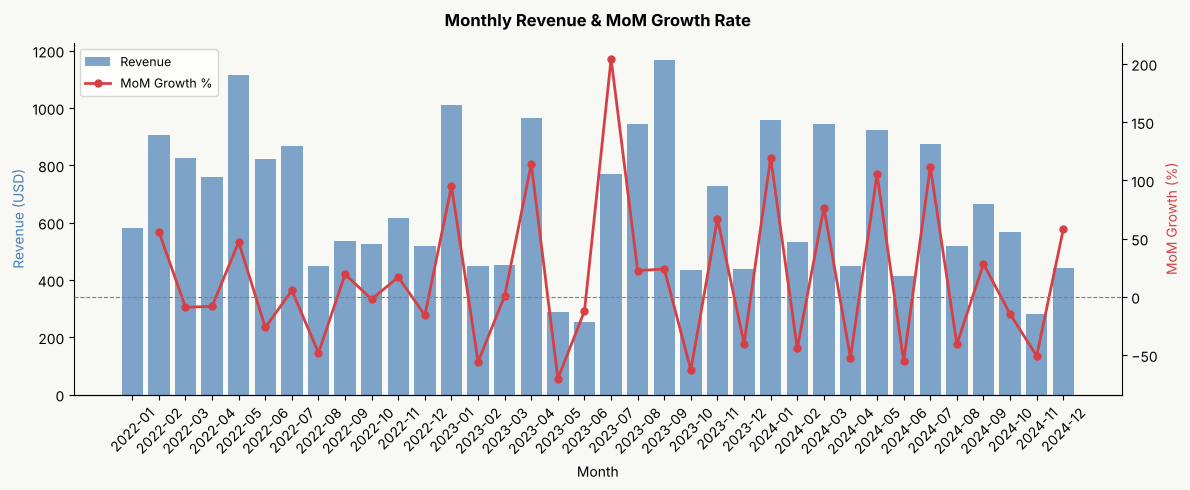

In [5]:
# Create a bar chart for monthly sales and a line chart for percentage change

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#F8F8F5")
ax1.set_facecolor("#F8F8F5")


ax1.bar(
    df_q2["month"], df_q2["total_sales"], color="#4A7FB5", alpha=0.7, label="Revenue"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (USD)", color="#4A7FB5")
ax1.tick_params(axis="x", rotation=45)
ax1.spines[["top", "right"]].set_visible(False)

# MoM growth rate line chart
ax2 = ax1.twinx()
ax2.plot(
    df_q2["month"],
    df_q2["percentage_change"],
    color="#D64045",
    linewidth=2,
    marker="o",
    markersize=5,
    label="MoM Growth %",
)
ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax2.set_ylabel("MoM Growth (%)", color="#D64045")
ax2.spines[["top", "left"]].set_visible(False)

ax1.set_title("Monthly Revenue & MoM Growth Rate", fontweight="bold", pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(
    "../images/mom_growth.png", dpi=150, bbox_inches="tight", facecolor="#F8F8F5"
)
plt.show()

In [6]:
# RFM (Recency, Frequency, Monetary) scoring to segment customers by purchasing behavior

query = """
WITH rfm AS (
    SELECT
        Customer_ID,
        CAST(JULIANDAY('2024-12-31') - JULIANDAY(MAX(Purchase_Date)) AS INT) AS recency_days,
        COUNT(*)                                                             AS frequency,
        ROUND(SUM(Total_Price), 2)                                           AS monetary
    FROM Transaction_Records
    WHERE Order_Completion_Status = 'Completed'
    GROUP BY Customer_ID
)
SELECT
    Customer_ID,
    recency_days,
    frequency,
    monetary,
    CASE
        WHEN recency_days <= 90  THEN 3
        WHEN recency_days <= 180 THEN 2
        ELSE 1
    END AS recency_score,
    CASE
        WHEN frequency >= 5 THEN 3
        WHEN frequency >= 3 THEN 2
        ELSE 1
    END AS frequency_score,
    CASE
        WHEN monetary >= 500 THEN 3
        WHEN monetary >= 200 THEN 2
        ELSE 1
    END AS monetary_score
FROM rfm
ORDER BY monetary DESC
"""

df = pd.read_sql_query(query, conn)
print(df)

    Customer_ID  recency_days  frequency  monetary  recency_score  \
0   Customer_26           117          5     634.0              2   
1   Customer_29           687          4     595.0              1   
2    Customer_9           469          3     567.0              1   
3   Customer_16           465          5     543.0              1   
4   Customer_10           454          4     542.0              1   
5   Customer_27           946          5     487.0              1   
6   Customer_17           158          3     459.0              2   
7   Customer_19           512          4     419.0              1   
8   Customer_12           175          5     412.0              2   
9    Customer_7           509          5     407.0              1   
10   Customer_5           300          3     385.0              1   
11   Customer_4            22          3     334.0              3   
12  Customer_28           360          2     327.0              1   
13  Customer_13           863     

In [7]:
# High-value customers at churn risk: top 30% by total spending, no purchase in the last 6 months

query = """
WITH customer_stats AS (
    SELECT
        Customer_ID,
        ROUND(SUM(Total_Price), 2)                                           AS total_spent,
        DATE(MAX(Purchase_Date))                                             AS last_purchase_date,
        CAST(JULIANDAY('2024-12-31') - JULIANDAY(MAX(Purchase_Date)) AS INT) AS days_since_last
    FROM Transaction_Records
    WHERE Order_Completion_Status = 'Completed'
    GROUP BY Customer_ID
),
ranked AS (
    SELECT
        *,
        NTILE(10) OVER (ORDER BY total_spent DESC) AS spent_decile
    FROM customer_stats
)
SELECT
    Customer_ID,
    total_spent,
    last_purchase_date,
    days_since_last,
    spent_decile
FROM ranked
WHERE spent_decile <= 3
  AND days_since_last > 180
ORDER BY total_spent DESC
"""

df_alerts = pd.read_sql_query(query, conn)
print(df_alerts)

   Customer_ID  total_spent last_purchase_date  days_since_last  spent_decile
0  Customer_29        595.0         2023-02-12              687             1
1   Customer_9        567.0         2023-09-18              469             1
2  Customer_16        543.0         2023-09-22              465             2
3  Customer_10        542.0         2023-10-03              454             2
4  Customer_27        487.0         2022-05-29              946             2
5  Customer_19        419.0         2023-08-06              512             3
